<a href="https://colab.research.google.com/github/FONDECYTACC/cons2025/blob/main/perf_by_strata_jan_ML_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Best predictors based on discrimination, permutation

## 0. Package loading and installation

In [2]:
# For Jupyter/Colab notebooks
%reset -f
import gc
gc.collect()

import numpy as np
import pandas as pd
import time

!pip install scikit-survival # Install scikit-survival if not already installed
!pip install miceforest --no-cache-dir
!pip install numpy

from sksurv.metrics import (
    concordance_index_ipcw,
    brier_score,
    integrated_brier_score
)
from sksurv.util import Surv

#Glimpse function
def glimpse(df, max_width=80):
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<30} {str(dtype):<15} {preview_str}")
#Tabyl function
def tabyl(series):
    counts = series.value_counts(dropna=False)
    props = series.value_counts(normalize=True, dropna=False)
    return pd.DataFrame({"value": counts.index,
                         "n": counts.values,
                         "percent": props.values})
#clean_names
import re

def clean_names(df):
    """
    Mimic janitor::clean_names for pandas DataFrames.
    - Lowercase
    - Replace spaces and special chars with underscores
    - Remove non-alphanumeric/underscore
    """
    new_cols = []
    for col in df.columns:
        # lowercase
        col = col.lower()
        # replace spaces and special chars with underscore
        col = re.sub(r"[^\w]+", "_", col)
        # strip leading/trailing underscores
        col = col.strip("_")
        new_cols.append(col)
    df.columns = new_cols
    return df


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 32.0 MB/s eta 0:00:00


In [3]:
from google.colab import userdata

# Names of the objects (and secrets)
object_names = [
    "imputations_list_jan26",
    "imputation_nodum_1",
    "X_reduced_imp0",
    "imputation_1"
]
for name in object_names:
    file_id = userdata.get(name)   # secret stored with this key
    if file_id is None:
        raise ValueError(f"No file_id found in userdata for key '{name}'")

    output_file = f"{name}.pkl"
    print(f"Downloading {name} -> {output_file}")
    !gdown {file_id} --output {output_file} --quiet

Load in python

In [4]:
import pandas as pd

# Example: load only imputation 1
imputation_nodum_1 = pd.read_parquet("/content/imputation_nodum_1.pkl")
X_reduced_imp0 = pd.read_parquet("/content/X_reduced_imp0.pkl")
imputation_1 = pd.read_parquet("/content/imputation_1.pkl")

# Quick check
glimpse(imputation_nodum_1)
glimpse(imputation_1)
glimpse(X_reduced_imp0)



Rows: 88504 | Columns: 41
readmit_time_from_adm_m        float64         84.93548387096774, 12.833333333333334, 13.733333333333333, 11.966666666666667, 1...
death_time_from_adm_m          float64         84.93548387096774, 87.16129032258064, 117.2258064516129, 98.93548387096774, 37.9...
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
sex_rec                        category        man, man, man, woman, man
tenure_status_household        category        stays temporarily with a relative, owner/transferred dwellings/pays dividends, s...
cohabitation                   category        alone, family of origin, with couple/children, with couple/children, family of o...
sub_dep_icd10_status           cat

In [5]:
import pickle
import pandas as pd
import numpy as np

file_path = '/content/imputations_list_jan26.pkl'

with open(file_path, 'rb') as f:
    imputations_list_jan26 = pickle.load(f)

print(f"Successfully loaded '{file_path}'\n")
print(f"Type of loaded object: {type(imputations_list_jan26)}")

if isinstance(imputations_list_jan26, list) and len(imputations_list_jan26) > 0:
    print("First element type:", type(imputations_list_jan26[0]))
    if isinstance(imputations_list_jan26[0], dict):
        print("First element keys:", imputations_list_jan26[0].keys())
    elif isinstance(imputations_list_jan26[0], (pd.DataFrame, np.ndarray)):
        print("First element shape:", imputations_list_jan26[0].shape)


Successfully loaded '/content/imputations_list_jan26.pkl'

Type of loaded object: <class 'list'>
First element type: <class 'pandas.core.frame.DataFrame'>
First element shape: (88504, 56)


This code block:

1.  **Imports the `pickle` library**: This library implements binary protocols for serializing and de-serializing a Python object structure.
2.  **Specifies the `file_path`**: It points to the `.pkl` file you selected.
3.  **Opens the file in binary read mode (`'rb'`)**: This is necessary for loading pickle files.
4.  **Loads the object**: `pickle.load(f)` reads the serialized object from the file and reconstructs it in memory.
5.  **Prints confirmation and basic information**: It verifies that the file was loaded and shows the type of the loaded object, and some details about the first element if it's a list containing common data structures.

#### Compare databases (transformed and original)

Inspect and compare the column names of two datasets: the first imputation from imputations_list_jan26 (which likely contains dummy variables) and imputation_nodum_1 (which, as its name suggests, probably doesn't have dummy variables).


In [6]:
# Inspect columns of the first imputation
cols_first_imp = imputations_list_jan26[0].columns.tolist()
print("First imputation columns:", cols_first_imp[:10], "... total:", len(cols_first_imp))

# Inspect columns of imputation_no_dum
cols_nodum = imputation_nodum_1.columns.tolist()
print("No-dum columns:", cols_nodum[:10], "... total:", len(cols_nodum))

# Compare overlap
common_cols = set(cols_first_imp).intersection(cols_nodum)
missing_in_imp = [c for c in cols_nodum if c not in cols_first_imp]
missing_in_nodum = [c for c in cols_first_imp if c not in cols_nodum]

print("Common columns:", len(common_cols))
print("Missing in imputations_list_jan26:", missing_in_imp)

First imputation columns: ['adm_age_rec3', 'porc_pobr', 'dit_m', 'tenure_status_household', 'prim_sub_freq_rec', 'national_foreign', 'urbanicity_cat', 'ed_attainment_corr', 'evaluacindelprocesoteraputico', 'eva_consumo'] ... total: 56
No-dum columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'sex_rec', 'tenure_status_household', 'cohabitation', 'sub_dep_icd10_status', 'any_violence'] ... total: 41
Common columns: 24
Missing in imputations_list_jan26: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'sex_rec', 'cohabitation', 'sub_dep_icd10_status', 'any_violence', 'tr_outcome', 'adm_motive', 'first_sub_used', 'primary_sub_mod', 'tipo_de_vivienda_rec2', 'plan_type_corr', 'occupation_condition_corr24', 'marital_status_rec', 'readmit_event', 'death_event', 'center_id']


In [7]:
# Inspect columns of the first imputation
cols_first_imp_raw = imputation_1.columns.tolist()
print("First imputation columns:", cols_first_imp_raw[:10], "... total:", len(cols_first_imp_raw))

# Compare overlap
common_cols_raw = set(cols_first_imp_raw).intersection(cols_nodum)
missing_in_imp_raw = [c for c in cols_nodum if c not in cols_first_imp_raw]

print("Common columns:", len(common_cols_raw))
print("Missing in imputations_list_jan26:", missing_in_imp_raw)
print(common_cols_raw)

First imputation columns: ['readmit_time_from_adm_m', 'death_time_from_adm_m', 'adm_age_rec3', 'porc_pobr', 'dit_m', 'national_foreign', 'ethnicity', 'dg_psiq_cie_10_instudy', 'dg_psiq_cie_10_dg', 'dx_f3_mood'] ... total: 78
Common columns: 16
Missing in imputations_list_jan26: ['sex_rec', 'tenure_status_household', 'cohabitation', 'sub_dep_icd10_status', 'any_violence', 'prim_sub_freq_rec', 'tr_outcome', 'adm_motive', 'first_sub_used', 'primary_sub_mod', 'tipo_de_vivienda_rec2', 'plan_type_corr', 'occupation_condition_corr24', 'marital_status_rec', 'urbanicity_cat', 'ed_attainment_corr', 'evaluacindelprocesoteraputico', 'eva_consumo', 'eva_fam', 'eva_relinterp', 'eva_ocupacion', 'eva_sm', 'eva_fisica', 'eva_transgnorma', 'center_id']
{'dit_m', 'dg_psiq_cie_10_dg', 'dx_f_any_severe_mental', 'polysubstance_strict', 'death_event', 'dx_f3_mood', 'readmit_time_from_adm_m', 'dx_f6_personality', 'death_time_from_adm_m', 'any_phys_dx', 'ethnicity', 'national_foreign', 'dg_psiq_cie_10_instudy'

In [8]:
import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars = ["adm_age_rec3", "porc_pobr", "dit_m"]

# Take one imputation (first element of the list) and merge with the no-dum dataset
df_imp = imputations_list_jan26[0]
df_nodum = imputation_nodum_1

merged_check = pd.merge(
    df_imp[key_vars],
    df_nodum[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check.shape[0]}")
print("Preview of merged check:")
print(merged_check.head())

#drop merge
del merged_check

Merged rows: 88516
Preview of merged check:
   adm_age_rec3  porc_pobr      dit_m
0         31.53   0.175679  15.967742
1         20.61   0.187836   5.833333
2         42.52   0.130412   0.475269
3         60.61   0.133759   6.966667
4         45.08   0.083189   6.903226


In [9]:
import pandas as pd

# Example: choose a combination of variables that uniquely identify rows
key_vars_raw = ['dit_m',
            'readmit_time_from_adm_m',
            'death_time_from_adm_m',
            'adm_age_rec3']
# Take one imputation (first element of the list) and merge with the no-dum dataset
df_raw = imputation_1

merged_check_raw = pd.merge(
    df_imp[key_vars],
    df_raw[key_vars],
    on=key_vars,
    how="inner"
)

print(f"Merged rows: {merged_check_raw.shape[0]}")
print("Preview of merged check:")
print(merged_check_raw.head())
print(f"{(merged_check_raw.shape[0] / imputation_1.shape[0] * 100):.2f}%")
#drop merge
del merged_check_raw

Merged rows: 88516
Preview of merged check:
   adm_age_rec3  porc_pobr      dit_m
0         31.53   0.175679  15.967742
1         20.61   0.187836   5.833333
2         42.52   0.130412   0.475269
3         60.61   0.133759   6.966667
4         45.08   0.083189   6.903226
100.01%


### Create bins for followup (landmarks)

This code prepares your data for survival analysis. It extracts the time until an event (like readmission or death) and whether that event actually happened for each patient from the df_nodum dataset. Then, it automatically creates a set of important time points, called an 'evaluation grid', which are specific moments to assess the model's performance on both readmission and death outcomes.


In [10]:
import numpy as np

# Required columns for survival outcomes
required = ["readmit_time_from_disch_m", "readmit_event",
            "death_time_from_disch_m", "death_event"]

# Check that df_raw has all required columns
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f"df_nodum is missing columns: {missing}")

# Create time/event arrays directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_nodum["death_event"].to_numpy() == 1)

print("Arrays created for df_raw:")
print("Readmission times:", time_readm[:5])
print("Readmission events:", event_readm[:5])
print("Death times:", time_death[:5])
print("Death events:", event_death[:5])

# Build evaluation grids (quantiles of event times)
event_times_readm = time_readm[event_readm]
event_times_death = time_death[event_death]

if len(event_times_readm) < 5 or len(event_times_death) < 5:
    raise ValueError("Too few events in df_raw to build reliable time grids.")

times_eval_readm = np.unique(np.quantile(event_times_readm, np.linspace(0.05, 0.95, 50)))
times_eval_death = np.unique(np.quantile(event_times_death, np.linspace(0.05, 0.95, 50)))

print("Eval times (readmission):", times_eval_readm[:5], "...", times_eval_readm[-5:])
print("Eval times (death):", times_eval_death[:5], "...", times_eval_death[-5:])


Arrays created for df_raw:
Readmission times: [84.93548387 12.83333333 13.73333333 11.96666667 14.25806452]
Readmission events: [False  True  True  True  True]
Death times: [ 84.93548387  87.16129032 117.22580645  98.93548387  37.93548387]
Death events: [False False False False False]
Eval times (readmission): [3.93548387 4.77419355 5.45058701 6.06492649 6.67741935] ... [54.44173469 58.41566162 63.23333333 68.54767171 74.68983871]
Eval times (death): [4.16290323 5.43022383 6.68564845 8.24254115 9.77961817] ... [81.92700461 85.41186103 88.78518762 93.5538183  99.21935484]


 ## Prepare data


First, we eliminated inmortal time bias (dead patients look like without readmission).

This correction is essentially the Cause-Specific Hazard preparation. It is the correct way to handle Aim 3 unless you switch to a Fine-Gray model (which treats death as a specific type of event 2, rather than censoring 0). For RSF/Coxnet, censoring 0 is the correct approach.

In [11]:
import numpy as np

# Step 1. Extract survival outcomes directly from df_raw
time_readm = df_raw["readmit_time_from_adm_m"].to_numpy()
event_readm = (df_raw["readmit_event"].to_numpy() == 1)

time_death = df_raw["death_time_from_adm_m"].to_numpy()
event_death = (df_raw["death_event"].to_numpy() == 1)

# Step 2. Build structured arrays (Surv objects)
y_surv_readm = np.empty(len(time_readm), dtype=[("event", "?"), ("time", "<f8")])
y_surv_readm["event"] = event_readm
y_surv_readm["time"] = time_readm

y_surv_death = np.empty(len(time_death), dtype=[("event", "?"), ("time", "<f8")])
y_surv_death["event"] = event_death
y_surv_death["time"] = time_death

# Step 3. Replicate across imputations
n_imputations = len(imputations_list_jan26)
y_surv_readm_list = [y_surv_readm for _ in range(n_imputations)]
y_surv_death_list = [y_surv_death for _ in range(n_imputations)]

import numpy as np

def correct_competing_risks(X_list, y_readm_list, y_death_list):
    """
    Adjust survival outcomes for competing risks (death vs. readmission).

    Parameters
    ----------
    X_list : list of pd.DataFrame
        Imputed predictor datasets (same rows across imputations).
    y_readm_list : list of structured arrays
        Surv(event, time) arrays for readmission.
    y_death_list : list of structured arrays
        Surv(event, time) arrays for death.

    Returns
    -------
    y_readm_corrected_list : list of structured arrays
        Corrected readmission outcomes (death treated as censoring).
    """
    corrected = []
    for y_readm, y_death in zip(y_readm_list, y_death_list):
        y_corr = y_readm.copy()
        # If patient died before readmission → censor at death time
        for i in range(len(y_corr)):
            if y_death["event"][i] and y_death["time"][i] < y_corr["time"][i]:
                y_corr["event"][i] = False
                y_corr["time"][i] = y_death["time"][i]
        corrected.append(y_corr)
    return corrected


# Step 4. Apply correction
y_surv_readm_list_corrected = correct_competing_risks(
    imputations_list_jan26,
    y_surv_readm_list,
    y_surv_death_list
)

In [12]:
# Check type and length
type(y_surv_readm_list_corrected), len(y_surv_readm_list_corrected)

# Look at the first element
y_surv_readm_list_corrected[0][:5]   # first 5 rows


array([(False, 84.93548387), ( True, 12.83333333), ( True, 13.73333333),
       ( True, 11.96666667), ( True, 14.25806452)],
      dtype=[('event', '?'), ('time', '<f8')])

In [13]:
glimpse(imputations_list_jan26[0])
print(y_surv_readm_list_corrected[0].shape, y_surv_readm_list_corrected[0].dtype)

Rows: 88504 | Columns: 56
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
tenure_status_household        int64           3, 0, 3, 0, 3
prim_sub_freq_rec              int64           1, 2, 2, 2, 2
national_foreign               int32           0, 0, 0, 0, 0
urbanicity_cat                 int64           0, 0, 0, 0, 0
ed_attainment_corr             float64         1.0, 2.0, 1.0, 1.0, 2.0
evaluacindelprocesoteraputico  int64           0, 2, 2, 2, 0
eva_consumo                    int64           0, 2, 2, 1, 0
eva_fam                        int64           1, 2, 2, 1, 0
eva_relinterp                  int64           0, 2, 2, 1, 0
eva_ocupacion                  int64           0, 2, 2, 2, 1
eva_sm     

# ML

### **Advanced Survival Modeling: XGBoost & Stratified Interpretability**

In this section, we transition from linear models to a **Gradient Boosted Decision Tree (GBDT)** framework using **XGBoost**. This non-linear approach is better suited to capture complex interactions between clinical variables that traditional Cox models might miss.

<details>
<summary style="cursor: pointer; font-weight: bold; font-size: 1.2em;">
    ▶ Click to expand
</summary>

<br>

#### **Methodological Framework:**
* **Non-Linear Survival Learning:** We utilize the `survival:cox` objective, which optimizes the Cox partial log-likelihood within a boosting architecture.
* **Stratified Cross-Validation:** To ensure the model generalizes across different clinical settings, we implement `StratifiedKFold`. This guarantees that each validation fold contains a proportional representation of treatment plans (Outpatient, Intensive, Residential, etc.).
* **Dynamic Performance Evaluation:** We calculate the **Cumulative Dynamic AUC**, providing a robust measure of how well the model discriminates risk across a time-dependent horizon.



#### **Model Explainability (SHAP):**
To resolve the "black-box" nature of XGBoost, we integrate **SHAP (SHapley Additive exPlanations)**. This allows us to decompose the risk prediction for every patient into the specific contributions of their features.



#### **Stratified Feature Importance:**
A unique feature of this pipeline is the **Intra-Strata Importance Analysis**. By masking SHAP values according to treatment plans, we identify specific risk drivers for each clinical subgroup, acknowledging that different programs (e.g., Residential vs. Outpatient) may have different triggers for the event.

</details>

In [14]:
# @title XGboost Survival Function {"display-mode":"form"}
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
from sksurv.metrics import cumulative_dynamic_auc
from sklearn.model_selection import StratifiedKFold
from sksurv.metrics import integrated_brier_score


# --- 1. Helper: Define Strata Masks ---
def get_strata_masks(df):
    masks = {}
    if 'plan_type_corr_pg_pr' in df.columns:
        masks['PG_PR (Outpatient)'] = df['plan_type_corr_pg_pr'] == 1
    if 'plan_type_corr_m_pr' in df.columns:
        masks['M_PR (Women Outpatient)'] = df['plan_type_corr_m_pr'] == 1
    if 'plan_type_corr_pg_pai' in df.columns:
        masks['PG_PAI (Intensive)'] = df['plan_type_corr_pg_pai'] == 1
    if 'plan_type_corr_m_pai' in df.columns:
        masks['M_PAI (Women Intensive)'] = df['plan_type_corr_m_pai'] == 1

    # Reference Group (Residential)
    all_others = np.zeros(len(df), dtype=bool)
    for m in masks.values():
        all_others = all_others | m
    masks['PG_PAB (Residential)'] = ~all_others
    return masks

# --- 2. Helper: Stratification Labels for CV ---
def get_stratification_labels(df):
    labels = np.zeros(len(df), dtype=int)
    if 'plan_type_corr_pg_pr' in df.columns: labels[df['plan_type_corr_pg_pr'] == 1] = 1
    if 'plan_type_corr_m_pr' in df.columns: labels[df['plan_type_corr_m_pr'] == 1] = 2
    if 'plan_type_corr_pg_pai' in df.columns: labels[df['plan_type_corr_pg_pai'] == 1] = 3
    if 'plan_type_corr_m_pai' in df.columns: labels[df['plan_type_corr_m_pai'] == 1] = 4
    return labels


# --- 3. Helper: Get survival probabilities of Cox ---
def get_breslow_survival_probs(y_train, train_risk, val_risk, times):
    """
    Computes the Breslow baseline survival and projects it to validation data.
    Returns a matrix of shape (n_val_samples, n_times).
    """
    # 1. Create a DF for training data to calculate baseline hazard
    df_train = pd.DataFrame({
        'time': y_train['time'],
        'event': y_train['event'],
        'risk_score': train_risk
    }).sort_values('time')

    # 2. Calculate the denominator (Risk Set) for Breslow Estimator
    # The risk set at time t includes all subjects with observed time >= t
    # We use reverse cumsum to get the sum of risks for everyone still 'alive'
    df_train['risk_at_risk'] = df_train['risk_score'][::-1].cumsum()[::-1]

    # 3. Calculate Baseline Hazard (dH) at event times only
    # Formula: dH(t) = events(t) / sum(risk_scores at risk at t)
    events = df_train[df_train['event'] == 1].groupby('time').agg({
        'event': 'sum',
        'risk_at_risk': 'first' # Take first because risk set is constant for tied times in this sort
    })

    events['hazard'] = events['event'] / events['risk_at_risk']
    events['cumulative_hazard'] = events['hazard'].cumsum()

    # 4. Get Baseline Survival S0(t) = exp(-H0(t))
    baseline_times = events.index.values
    baseline_surv = np.exp(-events['cumulative_hazard'].values)

    # 5. Project to Validation Data
    # Formula: S(t|x) = S0(t) ^ risk_score_x
    # We need to interpolate S0(t) to the specific 'times' requested

    # Use step function interpolation (post-value)
    # We use searchsorted to find the nearest baseline time for each requested time
    idx = np.searchsorted(baseline_times, times, side='right') - 1

    # Handle times before the first event (surv=1) or after last (use last known)
    # We create a safe lookup array
    safe_baseline_surv = np.concatenate(([1.0], baseline_surv))
    safe_idx = idx + 1 # shift indices to match the [1.0] prefix

    # Baseline survival probabilities at the requested 'times'
    S0_at_times = safe_baseline_surv[safe_idx]

    # Matrix multiplication to broadcast: S0(t)^risk_val
    # shape: (n_samples, n_times)
    surv_probs = S0_at_times[None, :] ** val_risk[:, None]

    return surv_probs

# --- 4. Main Evaluation Function ---
def evaluate_survival_xgboost(imputations_list, y_surv_list, target_name="Target"):
    pooled_c_indexes = []
    pooled_ibs_scores = []  # <--- NEW: Store IBS

    all_times = np.concatenate([y['time'] for y in y_surv_list])
    times = np.percentile(all_times[all_times > 0], np.linspace(10, 90, 15))

    last_model = None
    last_X = None

    print(f"\n=== Processing {target_name} ===")

    for idx, (df, y_structured) in enumerate(zip(imputations_list, y_surv_list)):
        X = df.copy()
        stratify_labels = get_stratification_labels(X)
        # XGBoost Cox expects labels: positive for events, negative for censored
        y_xgb = np.where(y_structured['event'], y_structured['time'], -y_structured['time'])

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        fold_c_indices = []
        fold_ibs_scores = [] # <--- NEW

        for train_idx, val_idx in skf.split(X, stratify_labels):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train_xgb, y_val_xgb = y_xgb[train_idx], y_xgb[val_idx]
            y_train_struc, y_val_struc = y_structured[train_idx], y_structured[val_idx]

            dtrain = xgb.DMatrix(X_train, label=y_train_xgb)
            dval = xgb.DMatrix(X_val, label=y_val_xgb)

            params = {
                'objective': 'survival:cox',
                'tree_method': 'hist', 'device': 'cuda', # or 'cpu' if no GPU
                'eval_metric': 'cox-nloglik', 'learning_rate': 0.05,
                'max_depth': 5, 'min_child_weight': 5,
                'subsample': 0.7, 'colsample_bytree': 0.7
            }

            model = xgb.train(params, dtrain, num_boost_round=1000,
                              evals=[(dval, 'val')], early_stopping_rounds=50,
                              verbose_eval=False)

            last_model = model
            last_X = X

            try:
                # 1. Get Raw Risk Scores (Hazard Ratios)
                # Note: output_margin=False (default) returns hazard ratio exp(beta*x)
                train_risk = model.predict(dtrain)
                val_risk = model.predict(dval)

                # 2. Compute C-Index (AUC) - Uses Risk Scores
                auc, mean_auc = cumulative_dynamic_auc(y_train_struc, y_val_struc, val_risk, times)
                fold_c_indices.append(mean_auc)

                # 3. Compute IBS - Uses Survival Probabilities
                # We must convert Risk -> Probability using Breslow
                surv_probs = get_breslow_survival_probs(y_train_struc, train_risk, val_risk, times)

                # Check valid range for IBS (train min/max)
                valid_times_mask = (times >= y_train_struc['time'].min()) & (times < y_train_struc['time'].max())
                if valid_times_mask.sum() > 1:
                     ibs = integrated_brier_score(y_train_struc, y_val_struc, surv_probs, times)
                     fold_ibs_scores.append(ibs)

            except ValueError as e:
                print(f"Error in metrics: {e}")
                pass

        pooled_c_indexes.append(np.mean(fold_c_indices))
        mean_ibs = np.mean(fold_ibs_scores) if fold_ibs_scores else np.nan
        pooled_ibs_scores.append(mean_ibs)

        print(f"  > Mean C-Index (Imp {idx}): {np.mean(fold_c_indices):.4f} | Mean IBS: {mean_ibs:.4f}")

    print(f"\n>>> Pooled C-Index: {np.mean(pooled_c_indexes):.4f} <<<")
    print(f">>> Pooled IBS:     {np.nanmean(pooled_ibs_scores):.4f} <<<") # Lower is better

    # Generate SHAP for the FINAL model
    print(f"Generating SHAP values for {target_name}...")
    explainer = shap.TreeExplainer(last_model)
    shap_values = explainer(last_X)

    return last_model, last_X, shap_values

# --- 4. Function to Create Stratified Importance Table ---
def get_importance_by_strata(X, shap_values, top_n=10):
    masks = get_strata_masks(X)
    strata_importance = {}

    # Handle SHAP object vs array
    vals = shap_values.values if hasattr(shap_values, 'values') else shap_values

    for name, mask_series in masks.items():
        mask = mask_series.values
        if mask.sum() < 10: continue

        local_imp = np.abs(vals[mask]).mean(axis=0)
        top_indices = np.argsort(local_imp)[::-1][:top_n]

        strata_importance[name] = [
            f"{X.columns[i]} ({local_imp[i]:.3f})" for i in top_indices
        ]

    return pd.DataFrame(strata_importance, index=range(1, top_n+1))

### Execute

In [15]:
# 1. READMISSION
model_readm_obj, X_readm, shap_readm = evaluate_survival_xgboost(
    imputations_list_jan26,
    y_surv_readm_list_corrected,
    target_name="Readmission"
)


=== Processing Readmission ===
  > Mean C-Index (Imp 0): 0.6431 | Mean IBS: 0.1623
  > Mean C-Index (Imp 1): 0.6438 | Mean IBS: 0.1623
  > Mean C-Index (Imp 2): 0.6434 | Mean IBS: 0.1623
  > Mean C-Index (Imp 3): 0.6432 | Mean IBS: 0.1622
  > Mean C-Index (Imp 4): 0.6434 | Mean IBS: 0.1621

>>> Pooled C-Index: 0.6434 <<<
>>> Pooled IBS:     0.1623 <<<
Generating SHAP values for Readmission...


In [16]:
# 2. DEATH
model_death_obj, X_death, shap_death = evaluate_survival_xgboost(
    imputations_list_jan26,
    y_surv_death_list,
    target_name="Death"
)



=== Processing Death ===
  > Mean C-Index (Imp 0): 0.7819 | Mean IBS: 0.0382
  > Mean C-Index (Imp 1): 0.7812 | Mean IBS: 0.0382
  > Mean C-Index (Imp 2): 0.7807 | Mean IBS: 0.0382
  > Mean C-Index (Imp 3): 0.7819 | Mean IBS: 0.0382
  > Mean C-Index (Imp 4): 0.7817 | Mean IBS: 0.0382

>>> Pooled C-Index: 0.7815 <<<
>>> Pooled IBS:     0.0382 <<<
Generating SHAP values for Death...


Here are the key takeaways from the code and results:

* **Robust Testing (Cross-Validation):** The code does not just test the model once; it splits your data into 5 parts and tests the model 5 separate times. The "Pooled C-Index" you see is the average of these 5 tests, making it a highly reliable "Gold Standard" accuracy score, not just a lucky guess.
* **Fair Comparisons (Stratification):** The code uses "Stratification" to ensure that every single test batch has the exact right mix of patients (e.g., 10% Residential, 40% Outpatient). This prevents the model from being tested only on "easy" cases and ensures the accuracy numbers apply to your whole population.
* **The Model "Sees" the Plan Type:** Even though we use the Plan Type to organize the testing splits, the model *also* gets to see the Plan Type as a predictor variable. This allows it to learn that being in a Residential program might carry a different baseline risk than being in Outpatient care.
* **Mortality Prediction is Excellent (0.78):** A C-Index of **0.78** for predicting death is a very strong clinical result. It means the model is highly effective at distinguishing between patients with high and low mortality risk, likely driven by stable factors like age and physical health.
* **Readmission Prediction is Good (0.64):** A C-Index of **0.64** for readmission is a solid, typical result for behavioral health. Predicting human behavior (like relapsing) is naturally harder than predicting biological outcomes (like death), but this score is still useful for identifying at-risk groups.
* **The Final Step (SHAP):** After calculating these accuracy scores, the code runs one final step to generate "SHAP values." This opens the "black box" of the model to show you exactly *which* variables (like Age or Poverty) drove those predictions for each specific Plan Type.

Generates comprehensive analysis:
1. Global Importance & Direction (Beeswarm Plot)
2. Functional Form of Top Continuous Variables (Dependence Plots)
3. Interaction Analysis (Top Interaction pairs)

In [17]:
# @title Importance function {"display-mode":"form"}

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def analyze_model_shap(X, shap_values, title_prefix="Outcome"):
    """
    Generates comprehensive analysis:
    1. Global Importance & Direction (Beeswarm Plot)
    2. Functional Form of Top Continuous Variables (Dependence Plots)
    3. Interaction Analysis (Top Interaction pairs)
    """

    # Ensure proper format
    if hasattr(shap_values, 'values'):
        vals = shap_values.values
        base_vals = shap_values.base_values
        data = shap_values.data
    else:
        vals = shap_values
        data = X.values

    # --- A. Global Importance & Direction (Beeswarm) ---
    print(f"\n>>> 1. {title_prefix}: Feature Direction & Importance <<<")
    print("   * Red dots = High variable value")
    print("   * Right side = Increased Risk (Higher Hazard)")
    print("   * Left side = Decreased Risk (Lower Hazard)")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X, show=False)
    plt.title(f"{title_prefix}: Impact Direction (Red = High Value)", fontsize=14)
    plt.show()

    # --- B. Functional Form (Curves) for Top Continuous Vars ---
    # Identify continuous columns (more than 10 unique values)
    continuous_cols = [c for c in X.columns if X[c].nunique() > 10]

    # Find top 3 continuous features by importance
    mean_abs_shap = np.mean(np.abs(vals), axis=0)
    top_indices = np.argsort(mean_abs_shap)[::-1]
    top_continuous = [X.columns[i] for i in top_indices if X.columns[i] in continuous_cols][:3]

    print(f"\n>>> 2. {title_prefix}: Functional Form (Non-Linearity Check) <<<")
    print(f"   Analyzing top continuous variables: {top_continuous}")

    for feat in top_continuous:
        plt.figure(figsize=(8, 4))
        shap.dependence_plot(
            feat,
            vals,
            X,
            interaction_index=None, # Clean view of the shape
            show=False,
            alpha=0.5
        )
        plt.title(f"Shape of '{feat}' on {title_prefix}\n(U-Shape = Quadratic, Curve = Log/Spline)", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.show()

    # --- C. Interaction Check (Standard Deviation of Effects) ---
    # Simple heuristic: If a variable's SHAP spread is wide for the same x-value, it interacts.
    print(f"\n>>> 3. {title_prefix}: Potential Interactions <<<")
    # We visually check this using dependence plots colored by the strongest interactor
    for feat in top_continuous:
        plt.figure(figsize=(8, 4))
        shap.dependence_plot(
            feat,
            vals,
            X,
            interaction_index="auto", # Automatically finds strongest interactor
            show=False,
            alpha=0.5
        )
        plt.title(f"Interaction: '{feat}' modified by another variable", fontsize=12)
        plt.show()



>>> 1. READMISSION: Feature Direction & Importance <<<
   * Red dots = High variable value
   * Right side = Increased Risk (Higher Hazard)
   * Left side = Decreased Risk (Lower Hazard)


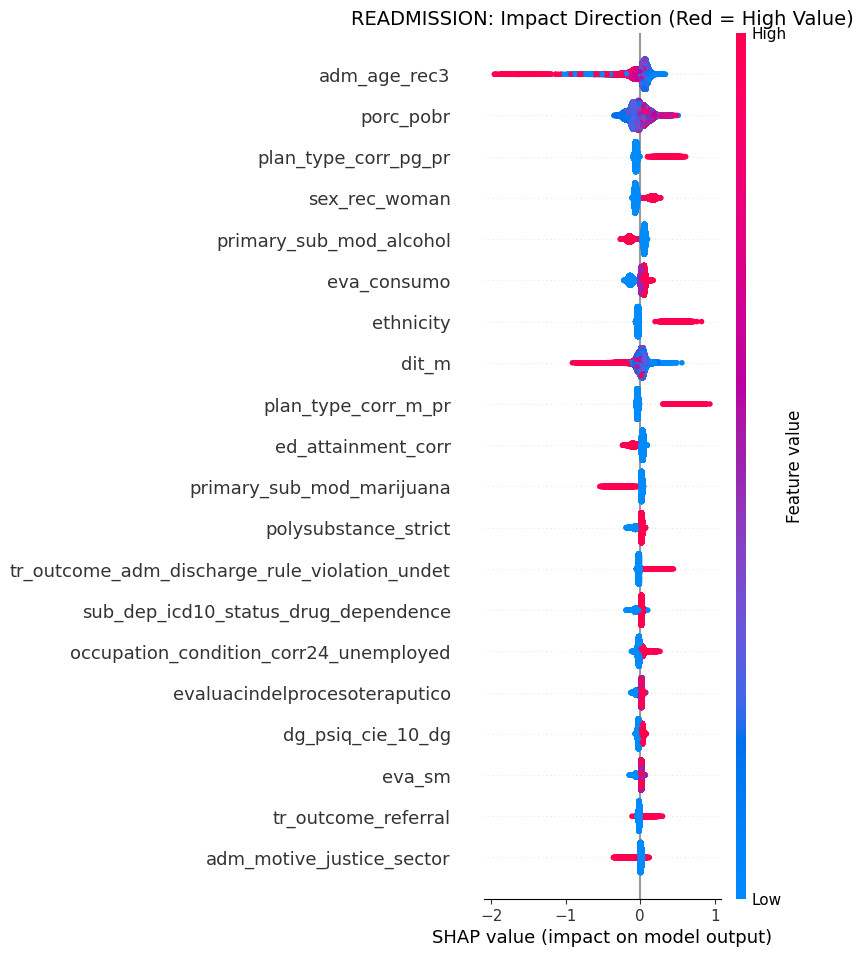


>>> 2. READMISSION: Functional Form (Non-Linearity Check) <<<
   Analyzing top continuous variables: ['adm_age_rec3', 'porc_pobr', 'dit_m']


<Figure size 800x400 with 0 Axes>

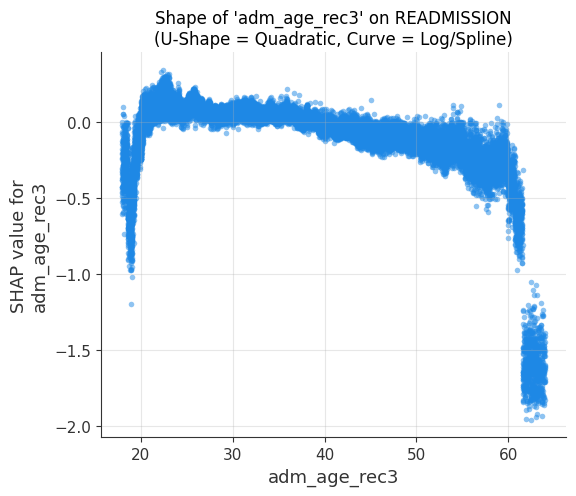

<Figure size 800x400 with 0 Axes>

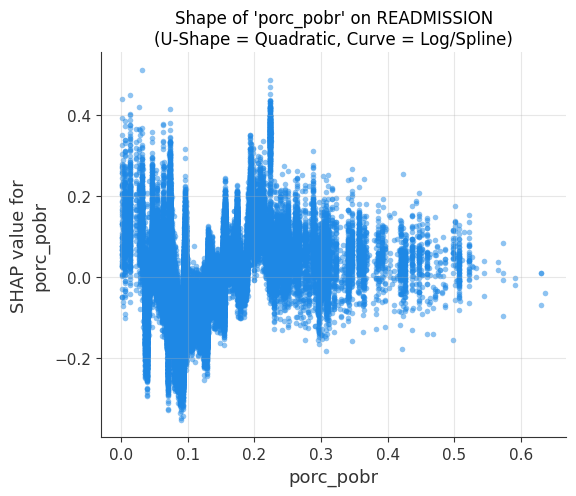

<Figure size 800x400 with 0 Axes>

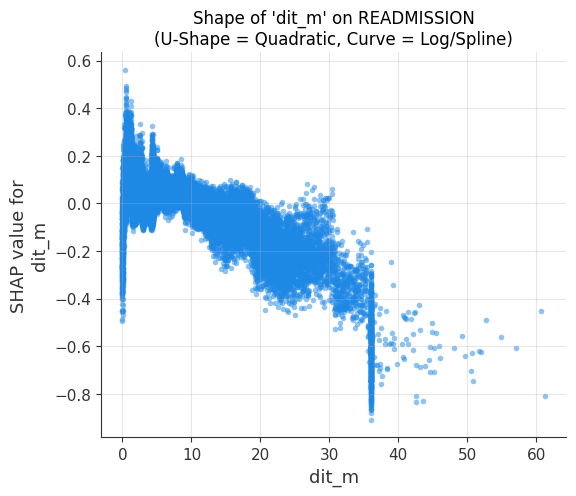


>>> 3. READMISSION: Potential Interactions <<<


<Figure size 800x400 with 0 Axes>

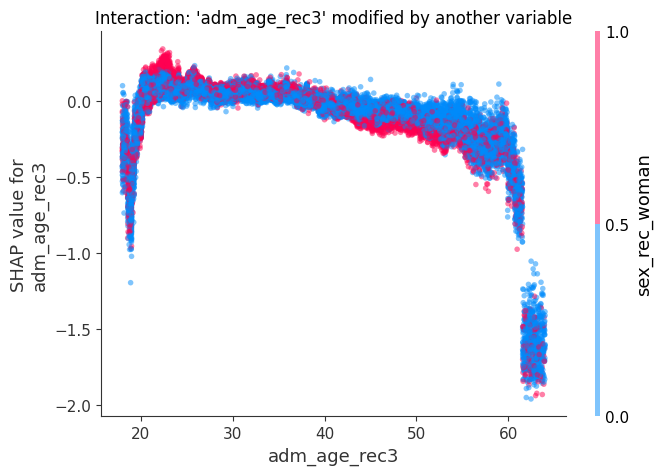

<Figure size 800x400 with 0 Axes>

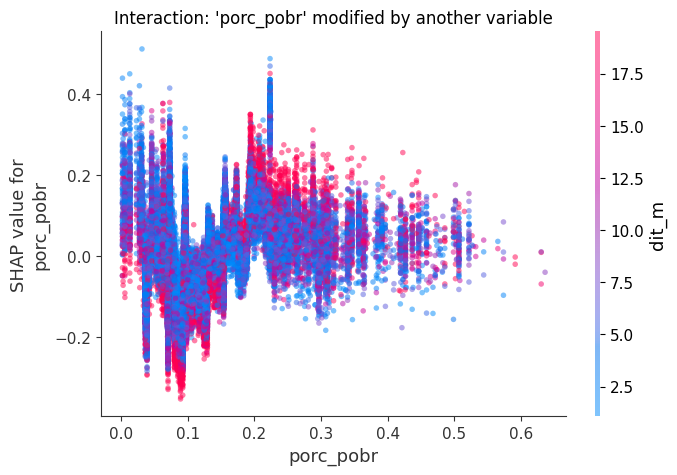

<Figure size 800x400 with 0 Axes>

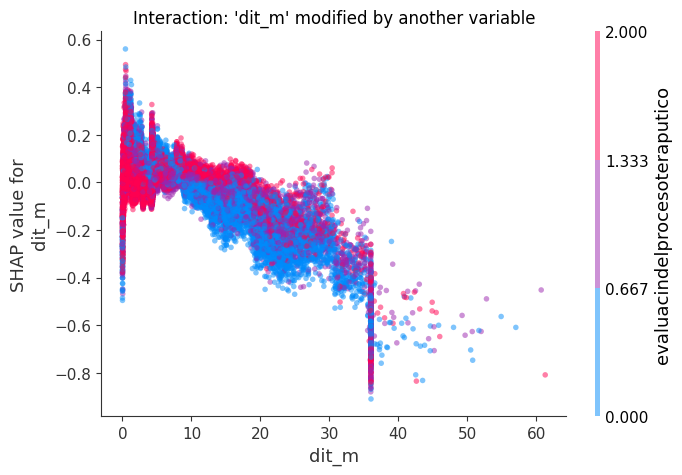

In [18]:
# 1. Analyze READMISSION
analyze_model_shap(X_readm, shap_readm, title_prefix="READMISSION")



>>> 1. DEATH: Feature Direction & Importance <<<
   * Red dots = High variable value
   * Right side = Increased Risk (Higher Hazard)
   * Left side = Decreased Risk (Lower Hazard)


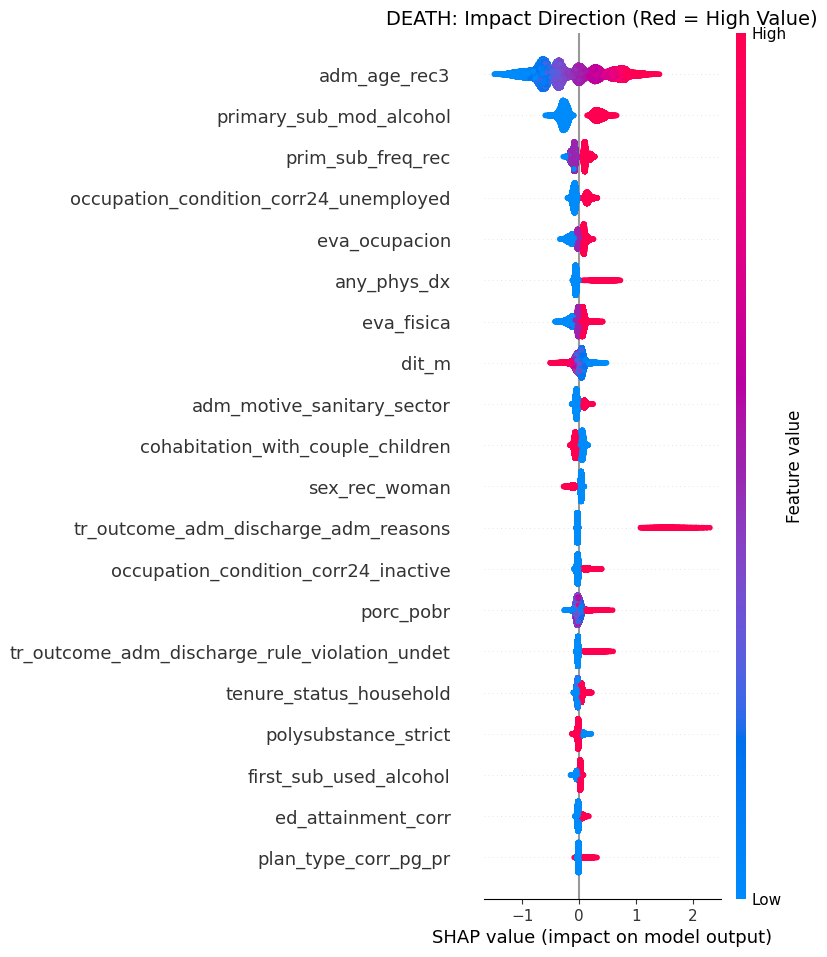


>>> 2. DEATH: Functional Form (Non-Linearity Check) <<<
   Analyzing top continuous variables: ['adm_age_rec3', 'dit_m', 'porc_pobr']


<Figure size 800x400 with 0 Axes>

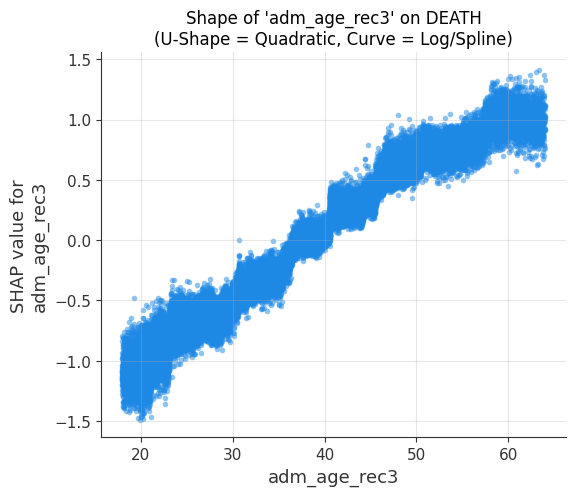

<Figure size 800x400 with 0 Axes>

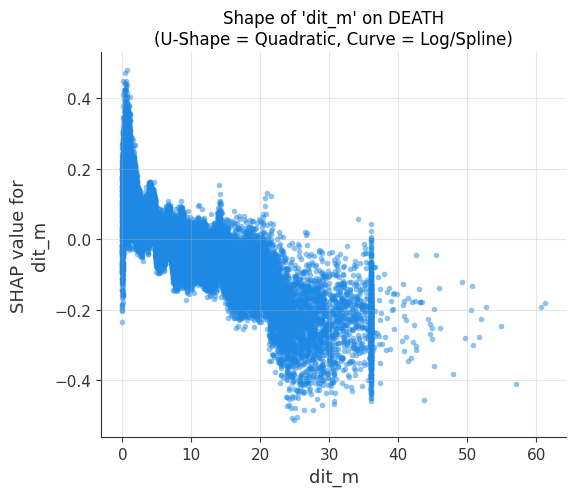

<Figure size 800x400 with 0 Axes>

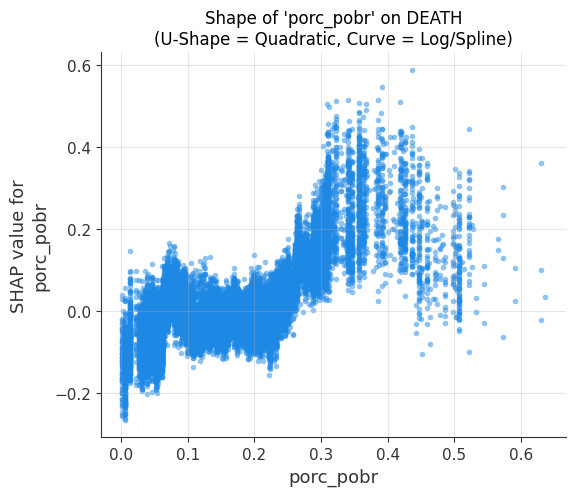


>>> 3. DEATH: Potential Interactions <<<


<Figure size 800x400 with 0 Axes>

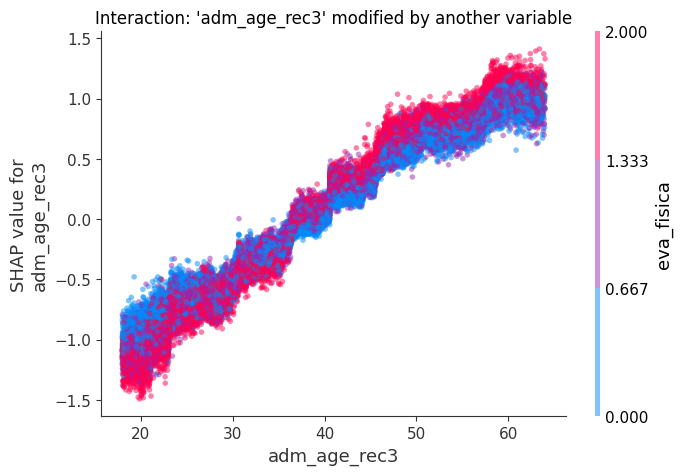

<Figure size 800x400 with 0 Axes>

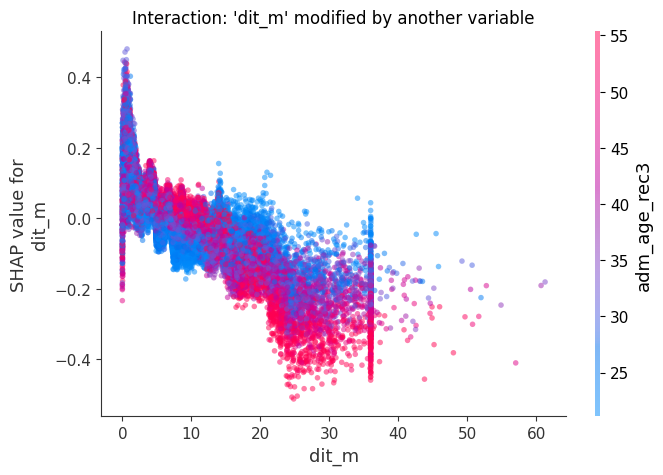

<Figure size 800x400 with 0 Axes>

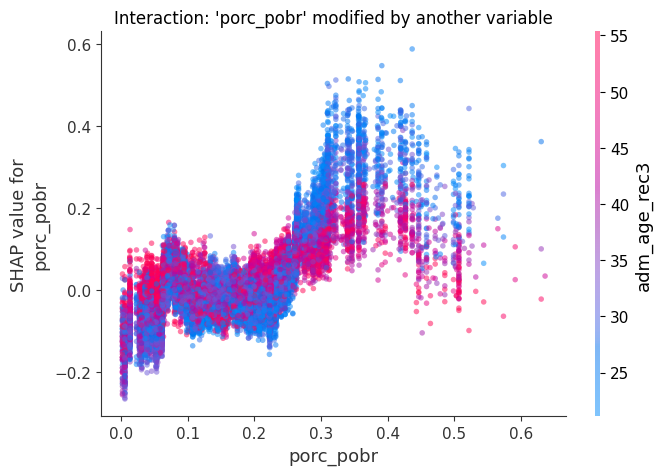

In [19]:
# 2. Analyze MORTALITY
analyze_model_shap(X_death, shap_death, title_prefix="DEATH")

Extract SHAP and display

In [20]:
import numpy as np
import pandas as pd
import shap
from scipy.stats import spearmanr

def get_feature_interaction_report(model, X, outcome_name="Outcome", subsample_size=2000):
    """
    Calculates Main Effects vs. Interaction Effects and returns a ranked DataFrame.
    Includes 'Direction' (Positive/Negative risk) for main effects.
    """
    print(f"\n--- Analyzing Interactions for {outcome_name} ---")

    # 1. Subsample for Speed/Memory safety
    if len(X) > subsample_size:
        X_sub = X.sample(n=subsample_size, random_state=42)
    else:
        X_sub = X.copy()

    # 2. Calculate SHAP Interaction Values (3D Matrix)
    # Shape: (N_samples, N_features, N_features)
    explainer = shap.TreeExplainer(model)
    # This step might take 30-60s
    shap_interactions = explainer.shap_interaction_values(X_sub)

    # 3. Extract Mean Absolute Importance
    # The matrix is symmetric.
    # Diagonal = Main Effect. Off-Diagonal = Interaction Effect (divided by 2).

    mean_interaction = np.abs(shap_interactions).mean(0) # Average over samples -> (F, F)

    results = []

    for i, col_i in enumerate(X_sub.columns):
        for j, col_j in enumerate(X_sub.columns):
            # To avoid duplicates, only take upper triangle (j >= i)
            if j < i:
                continue

            val = mean_interaction[i, j]

            # MAIN EFFECT (Diagonal)
            if i == j:
                # Check Direction: Correlate Feature Value with its SHAP Main Effect
                # Pos Corr = Higher Value increases Risk (Red dots on Right)
                # Neg Corr = Higher Value decreases Risk (Red dots on Left)

                # Get main effect vector for correlation
                main_effect_vec = shap_interactions[:, i, i]
                feature_vec = X_sub.iloc[:, i].values

                # Handle constant columns to avoid warnings
                if np.std(feature_vec) == 0:
                    direction = "Neutral"
                else:
                    corr, _ = spearmanr(feature_vec, main_effect_vec)
                    direction = "(+) Risk Increases" if corr > 0 else "(-) Risk Decreases"

                results.append({
                    "Type": "Main Effect",
                    "Feature A": col_i,
                    "Feature B": "-",
                    "Importance": val,
                    "Direction/Note": direction
                })

            # INTERACTION EFFECT (Off-Diagonal)
            else:
                # Multiply by 2 because SHAP splits interaction credit equally between i,j and j,i
                interaction_val = val * 2

                if interaction_val > 0.001: # Filter tiny noise
                    results.append({
                        "Type": "Interaction",
                        "Feature A": col_i,
                        "Feature B": col_j,
                        "Importance": interaction_val,
                        "Direction/Note": "Complex (See Plot)"
                    })

    # 4. Create DataFrame and Sort
    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by="Importance", ascending=False).reset_index(drop=True)

    # Normalize Importance to %
    total_imp = df_res['Importance'].sum()
    df_res['Relative %'] = (df_res['Importance'] / total_imp) * 100

    return df_res.head(20) # Return Top 20


In [21]:
print("Generating Readmission Report...")
# Note: X_readm comes from the `evaluate_survival_xgboost` output
df_report_readm = get_feature_interaction_report(model_readm_obj, X_readm, "Readmission")

# Display
print("\n>>> TOP DRIVERS: READMISSION <<<")
display(df_report_readm)


Generating Readmission Report...

--- Analyzing Interactions for Readmission ---

>>> TOP DRIVERS: READMISSION <<<


,Type,Feature A,Feature B,Importance,Direction/Note,Relative %
0,Main Effect,adm_age_rec3,-,0.103448,(-) Risk Decreases,4.171322
1,Main Effect,primary_sub_mod_alcohol,-,0.091065,(-) Risk Decreases,3.671989
2,Main Effect,sex_rec_woman,-,0.085314,(+) Risk Increases,3.440107
3,Main Effect,plan_type_corr_pg_pr,-,0.084067,(+) Risk Increases,3.389809
4,Main Effect,porc_pobr,-,0.080258,(+) Risk Increases,3.236223
5,Main Effect,eva_consumo,-,0.069644,(+) Risk Increases,2.808231
6,Main Effect,ethnicity,-,0.053941,(+) Risk Increases,2.175060
7,Main Effect,plan_type_corr_m_pr,-,0.052291,(+) Risk Increases,2.108504
8,Main Effect,dit_m,-,0.050789,(-) Risk Decreases,2.047951
9,Main Effect,ed_attainment_corr,-,0.050379,(-) Risk Decreases,2.031430


In [22]:

print("Generating Mortality Report...")
df_report_death = get_feature_interaction_report(model_death_obj, X_death, "Death")

print("\n>>> TOP DRIVERS: DEATH <<<")
display(df_report_death)

Generating Mortality Report...

--- Analyzing Interactions for Death ---

>>> TOP DRIVERS: DEATH <<<


/tmp/ipython-input-20-1920654274.py:55: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(feature_vec, main_effect_vec)


,Type,Feature A,Feature B,Importance,Direction/Note,Relative %
0,Main Effect,adm_age_rec3,-,0.535157,(+) Risk Increases,12.838682
1,Main Effect,primary_sub_mod_alcohol,-,0.312792,(+) Risk Increases,7.504026
2,Main Effect,prim_sub_freq_rec,-,0.118806,(+) Risk Increases,2.850217
3,Main Effect,occupation_condition_corr24_unemployed,-,0.107178,(+) Risk Increases,2.571258
4,Main Effect,eva_ocupacion,-,0.098428,(+) Risk Increases,2.361328
5,Main Effect,any_phys_dx,-,0.092334,(+) Risk Increases,2.215127
6,Main Effect,eva_fisica,-,0.084394,(+) Risk Increases,2.024651
7,Interaction,adm_age_rec3,primary_sub_mod_alcohol,0.066553,Complex (See Plot),1.596649
8,Main Effect,cohabitation_with_couple_children,-,0.065781,(-) Risk Decreases,1.578119
9,Interaction,prim_sub_freq_rec,primary_sub_mod_alcohol,0.063627,Complex (See Plot),1.526453


### Plot

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import shap
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 1. Setup Strata Definitions ---
def get_strata_masks(df):
    masks = {}

    # 1. PG_PR (Outpatient)
    if 'plan_type_corr_pg_pr' in df.columns:
        masks['PG_PR (Outpatient)'] = df['plan_type_corr_pg_pr'] == 1

    # 2. M_PR (Women Outpatient)
    if 'plan_type_corr_m_pr' in df.columns:
        masks['M_PR (Women Outpatient)'] = df['plan_type_corr_m_pr'] == 1

    # 3. PG_PAI (Intensive)
    if 'plan_type_corr_pg_pai' in df.columns:
        masks['PG_PAI (Intensive)'] = df['plan_type_corr_pg_pai'] == 1

    # 4. M_PAI (Women Intensive)
    if 'plan_type_corr_m_pai' in df.columns:
        masks['M_PAI (Women Intensive)'] = df['plan_type_corr_m_pai'] == 1

    # 5. PG_PAB (Residential - Reference Group)
    all_others = np.zeros(len(df), dtype=bool)
    for m in masks.values():
        all_others = all_others | m
    masks['PG_PAB (Residential)'] = ~all_others

    return masks

# --- 2. Generate Stratified Plots ---
def plot_transformations_by_strata(model, X, shap_vals, features_to_plot):
    masks = get_strata_masks(X)

    # Setup Figure
    n_features = len(features_to_plot)
    n_strata = len(masks)

    fig, axes = plt.subplots(n_features, n_strata, figsize=(4 * n_strata, 4 * n_features), sharey='row')

    # Ensure axes is always 2D
    if n_features == 1: axes = np.array([axes])
    if n_strata == 1: axes = axes.reshape(n_features, 1)

    # Handle SHAP object vs Array
    if hasattr(shap_vals, 'values'):
        shap_vals = shap_vals.values
    shap_vals = np.array(shap_vals)

    for row_idx, feature in enumerate(features_to_plot):
        x_min, x_max = X[feature].min(), X[feature].max()
        feat_idx = X.columns.get_loc(feature)

        for col_idx, (strata_name, mask_series) in enumerate(masks.items()):
            ax = axes[row_idx][col_idx] if n_features > 1 else axes[col_idx]

            mask = mask_series.values
            if mask.sum() < 10:
                ax.text(0.5, 0.5, "Insufficient Data", ha='center', transform=ax.transAxes)
                continue

            # Filter Data
            x_data = X.loc[mask, feature].values
            y_shap = shap_vals[mask][:, feat_idx]

            # Scatter Plot
            ax.scatter(x_data, y_shap, alpha=0.3, s=10, color='#1f77b4')

            # Lowess Smoothing Line
            try:
                # Sort for clean plotting
                sorted_idx = np.argsort(x_data)
                x_sorted = x_data[sorted_idx]
                y_sorted = y_shap[sorted_idx]

                # Calculate curve
                smooth_curve = lowess(y_sorted, x_sorted, frac=0.6)
                ax.plot(smooth_curve[:, 0], smooth_curve[:, 1], color='red', lw=2)
            except:
                pass

            ax.set_title(f"{strata_name}\n(N={mask.sum()})", fontsize=10)

            if col_idx == 0:
                ax.set_ylabel(f"Risk Impact\n({feature})", fontsize=11)
            if row_idx == n_features - 1:
                ax.set_xlabel(feature)

            ax.set_xlim(x_min, x_max)
            ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

>>> Stratified Functional Forms: READMISSION <<<


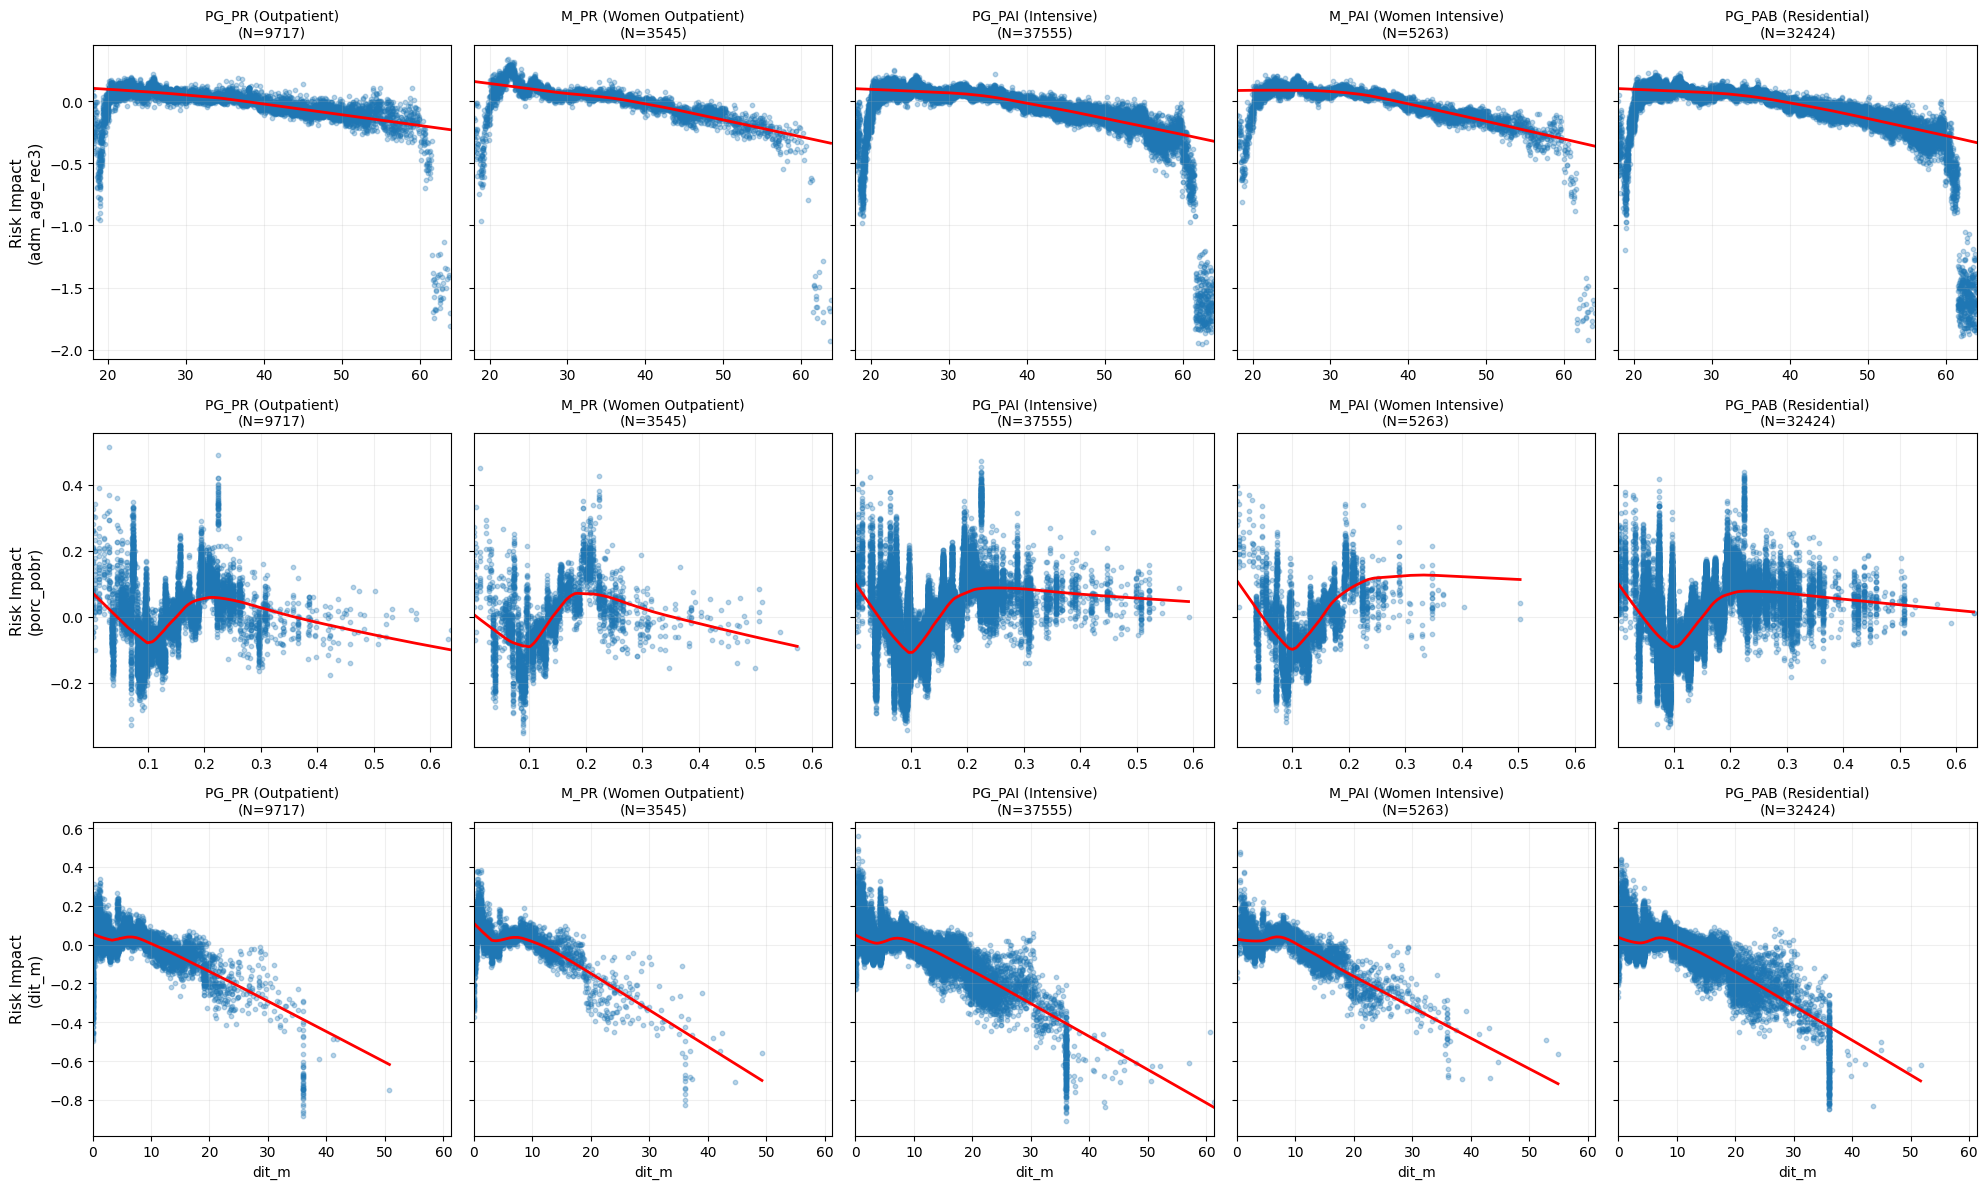

In [24]:

# --- 3. EXECUTION ---
vars_to_check = ['adm_age_rec3', 'porc_pobr', 'dit_m']

print(">>> Stratified Functional Forms: READMISSION <<<")
# Uses model_readm_obj, X_readm, shap_readm from previous steps
plot_transformations_by_strata(model_readm_obj, X_readm, shap_readm, vars_to_check)




>>> Stratified Functional Forms: DEATH <<<


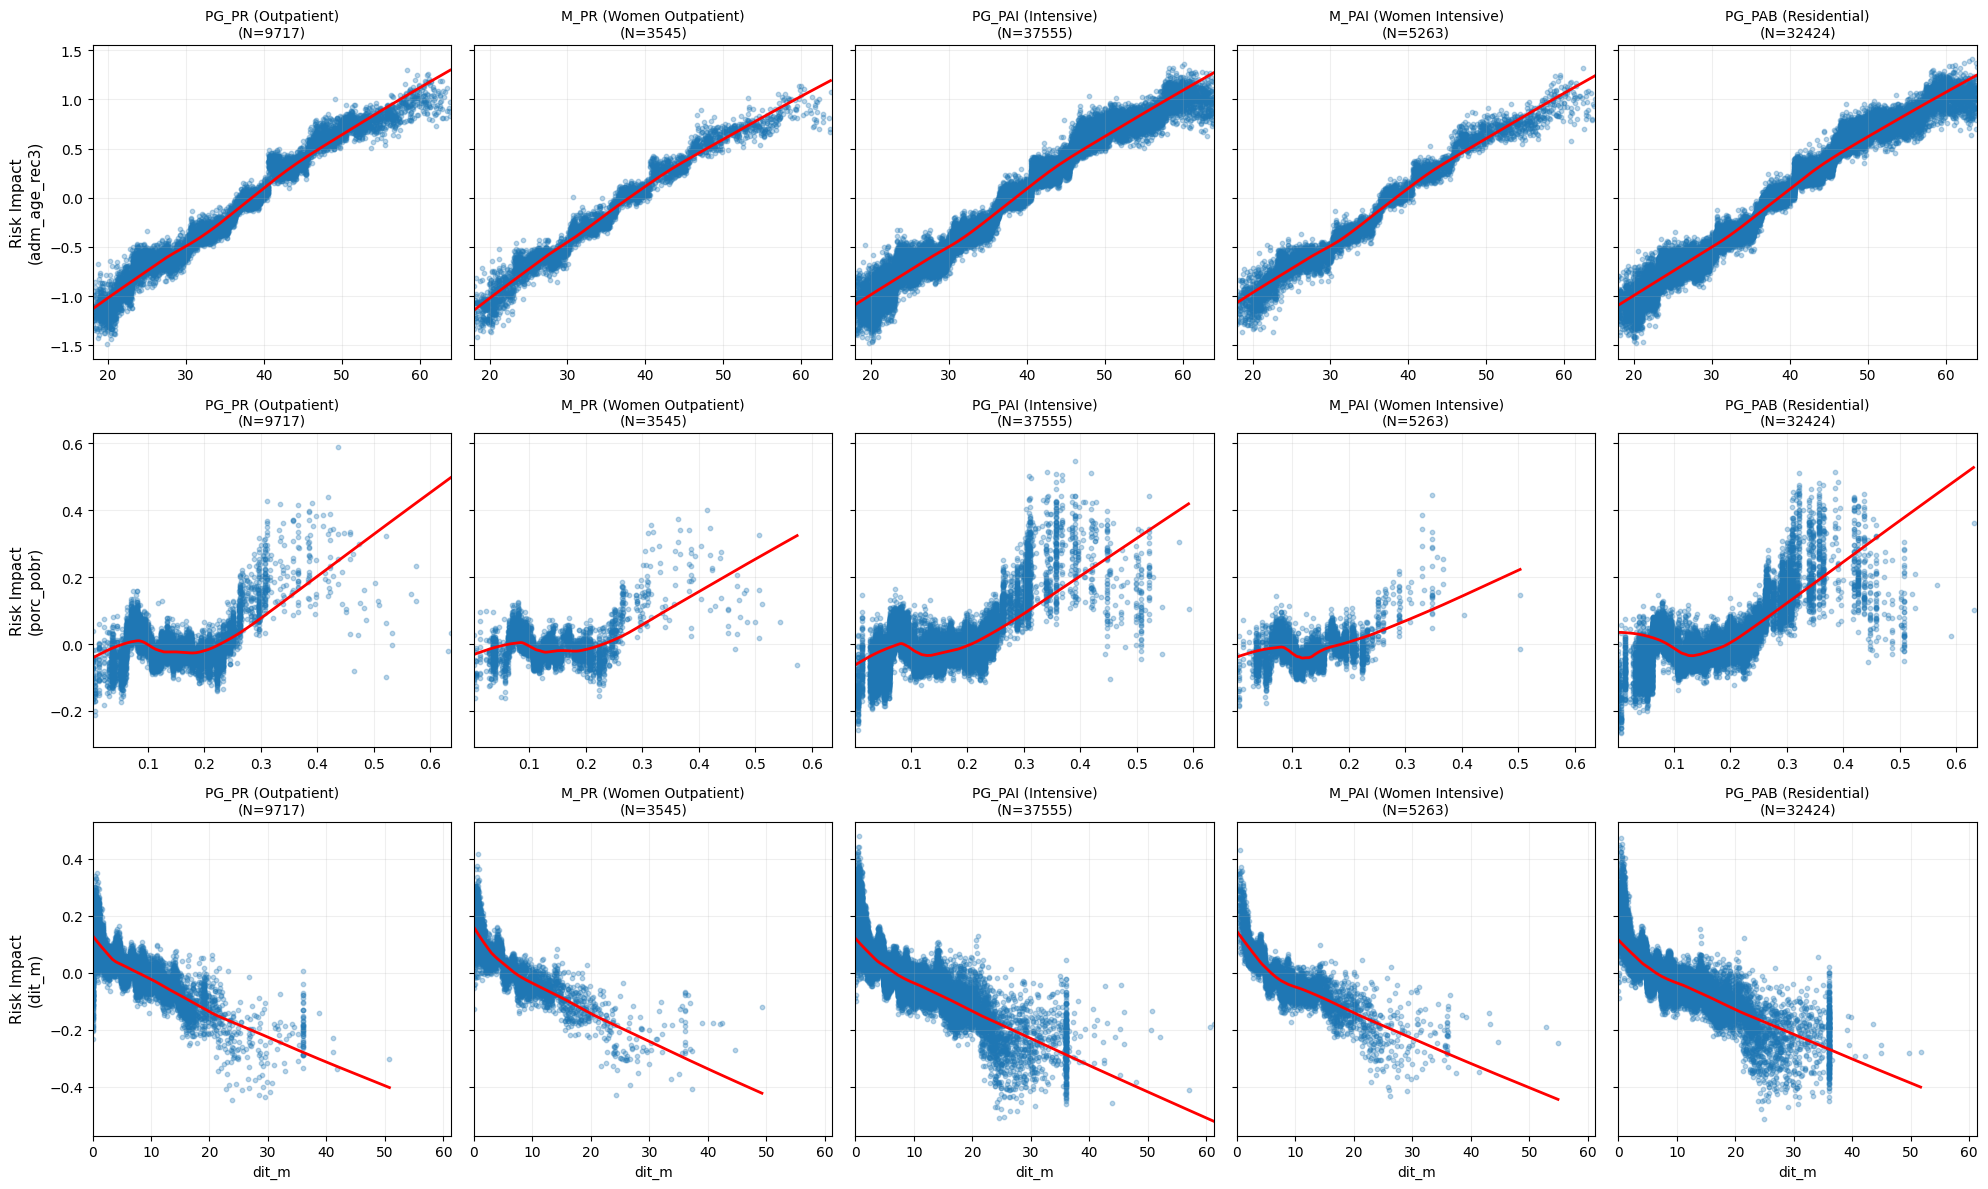

In [25]:

print("\n\n>>> Stratified Functional Forms: DEATH <<<")
# Uses model_death_obj, X_death, shap_death from previous steps
plot_transformations_by_strata(model_death_obj, X_death, shap_death, vars_to_check)

| Feature   | Readmission Behavior                          | Mortality Behavior                          | Cox Strategy                                      |
|-----------|-----------------------------------------------|---------------------------------------------|--------------------------------------------------|
| Age       | Flat / Slight Decline (Older is safer/neutral) | Strong Linear Increase (Older is riskier)   | Readmission: Linear (Negative coeff) <br> Death: Linear (Positive coeff) |
| Poverty   | Threshold Effect (Risk starts > 20%)          | Threshold Effect (Risk starts > 25%)        | Both: Spline/Hinge max(0, x - 0.25)              |
| Duration  | Diminishing Returns (Log shape)               | Diminishing Returns (Log shape)             | Both: Log transform log(x + 1)                   |



Captures the risk that only starts after 25% poverty

